In [ ]:
import time
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from concrete.ml.sklearn import LinearRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error 
from sklearn.metrics import mean_absolute_error 
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_percentage_error 
from sklearn.metrics import explained_variance_score

# Evaluation Baseline - Regression Models

### Make classification samples and perform train and test split

Min
- Tells us how small the smallest value is across all features and samples.
- Useful to check if your features contain negative values which are important for certain models sensitive to input ranges as well as quantization which may work better with normalized or strictly postive ranges

Max
- Shows how large the largest value is across all features and samples
- Helps assess whether outliers exist and if scaling/normalization may help improve model performance or stability

In [2]:
x, y = make_regression(n_samples=100, n_features=1, n_targets=1, bias=5.0, noise=30.0, random_state=42)
print("X Minimum: ", x.min())
print("X Maximum: ", x.max())

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42)

X Minimum:  -2.6197451040897444
X Maximum:  1.8522781845089378


### Evaluate number of training and testing samples from train/test split

Number of Samples
- Ensures you have enough data to train and evaluate the model effectively
- Confirms train/test split proportions are appropriate for fair performance assessment

Shape of Data
- Verifies the feature dimensions match the model's input expectations
- Helps detect structural issues like missing values, reshaping errors or misaligned label arrays

In [3]:
num_x_training = len(x_train)
num_x_test = len(x_test)
num_y_training = len(y_train)
num_y_test = len(y_test)

print("Number of x training: ", num_x_training)
print("Number of x test: ", num_x_test)
print("Number of y training: ", num_y_training)
print("Number of y test: ", num_y_test)

Number of x training:  90
Number of x test:  10
Number of y training:  90
Number of y test:  10


In [4]:
print("x_train shape: ", x_train.shape)
print("x_test shape: ", x_test.shape)
print("y_train shape: ", y_train.shape)
print("y_test shape: ", y_train.shape) 

x_train shape:  (90, 1)
x_test shape:  (10, 1)
y_train shape:  (90,)
y_test shape:  (90,)


### Initialise Model and Perform Fitting and Prediction

In [5]:
total_start_time = time.time()

model = LinearRegression(n_bits=8)

ml_start_time = time.time()

model.fit(x_train, y_train)
y_pred_clear = model.predict(x_test)
model.compile(x_train)

ml_end_time = time.time()

[cctools-port]: generating fake signature for '/var/folders/np/csvtz3fn3w5gwpvph62t5y180000gn/T/tmpv8x3spkv/sharedlib.dylib'


### Evaluate accuracy performed on the cleartext during prediction

Mean Squared Error (MSE)
- Measures average squared difference between predicted and actual values
- Penalizes large errors more than small ones due to squaring
- Lower is better, zero means perfect prediction

Mean Absolute Error (MAE)
- Measures average absolute difference between predicted and actual values
- Less sensitive to outliers than MSE
- GIves a more intuitive error magnitude in the same units as your target

Mean Absolute Percentage Error (MAPE)
- Measures average error as a percentage of actual values
- Helps understand relative error
- Useful when you care about percentage deviation, but can be problematic if actual values are close to zero

R-squared Score (R2)
- Indicates how much variance in the target variable is explained by the model
- Ranges from 0 to 1 -> 1 is perfect git, 0 is predicts mean only, and less than 0 is worse than mean model

Explained Variance Score (EVS)
- Measures the proportion of the variance explained by the predictions
- Similar to R2, but not penalized for model bias
- Score of 1 means all variance is captured, 0 means none

Elapsed Time (ML Prediction Time)
- Reflects how fast the model can predict in cleartext
- Useful for comparing with FHE execution time to assess performance trade-offs


In [6]:
clear_mse = mean_squared_error(y_test, y_pred_clear)
clear_mae = mean_absolute_error(y_test, y_pred_clear)
clear_mape = mean_absolute_percentage_error(y_test, y_pred_clear)
clear_r2 = r2_score(y_test, y_pred_clear)
clear_explained_var = explained_variance_score(y_test, y_pred_clear)
ml_elapsed_time = ml_end_time - ml_start_time

print("Mean Squared Error (MSE):", clear_mse)
print("Mean Absolute Error (MAE):", clear_mae)
print("Mean Absolute Percentage Error (MAPE):", clear_mape)
print("R-squared Score (R²):", clear_r2)
print("Explained Variance Score (EVS):", clear_explained_var)
print(f"Time it took for ML to make predictions: {ml_elapsed_time:.5f} seconds")

Mean Squared Error (MSE): 1170.1469904739056
Mean Absolute Error (MAE): 29.23528899387278
Mean Absolute Percentage Error (MAPE): 1.026348459498222
R-squared Score (R²): 0.6684359976906726
Explained Variance Score (EVS): 0.8221459912801368
Time it took for ML to make predictions: 0.15760 seconds


### Prediction v Actual Plot - Cleartext

- Shows how well the predicted values align with the actual test values
- Points close to the red dashed line indicate high prediction accuracy
- A consistent pattern above or below the line may reveal bias in the model
- Wide spread of points suggests poor model fit or high error
- Tighter cluster around the line indicates strong model performance

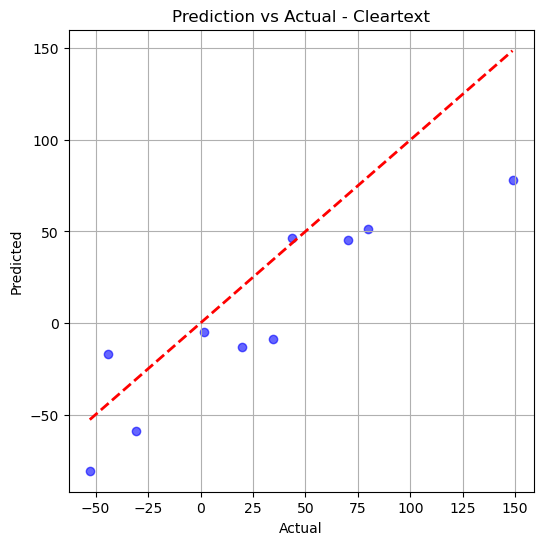

In [7]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_clear, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Prediction vs Actual - Cleartext")
plt.grid(True)
plt.show()

### Residual Plot - Cleartext
- Visualizes the errors (residuals) between predicated and actual values
- Points randomly scattered around the red line (y=0) indicate a good fit
- A clear pattern or curve in the residuals suggests the model is missing some structure in the data
- Large spread in residuals implies high variance or inconsistent predictions
- CLustering or funnel shapes can signal uneven variance

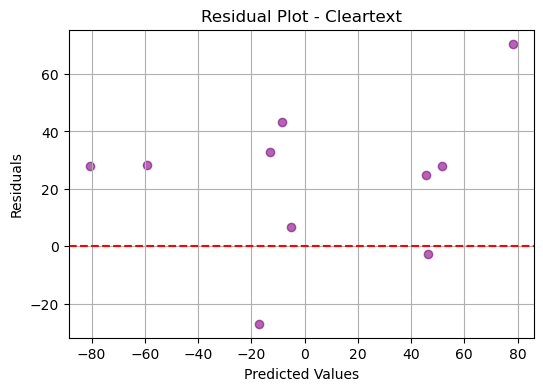

In [8]:
residuals = y_test - y_pred_clear

plt.figure(figsize=(6, 4))
plt.scatter(y_pred_clear, residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - Cleartext")
plt.grid(True)
plt.show()

### Residual Histogram - Cleartext
- Shows the distribution of prediction errors
- Bell-shaped distribution indicates that the model's errors are random and unbiased
- Skewed or lopsided histograms suggest systematic error or bias in predictions
- Multiple peaks may indicate missing variables or mixed patterns in the data
- Long tails imply the presence of outliers or exterme prediction errors

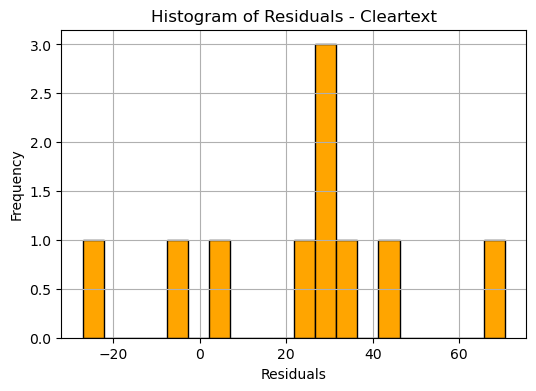

In [9]:
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=20, color='orange', edgecolor='black')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals - Cleartext")
plt.grid(True)
plt.show()

### FHE Execution and Evaluation

In [10]:
fhe_prediction_start_time = time.time()

y_pred_fhe = model.predict(x_test, fhe="execute")

fhe_prediction_end_time = time.time()

### Evaluate accuracy performed during FHE prediction

Mean Squared Error (MSE)
- Measures average squared difference between predicted and actual values
- Penalizes large errors more than small ones due to squaring
- Lower is better, zero means perfect prediction

Mean Absolute Error (MAE)
- Measures average absolute difference between predicted and actual values
- Less sensitive to outliers than MSE
- GIves a more intuitive error magnitude in the same units as your target

Mean Absolute Percentage Error (MAPE)
- Measures average error as a percentage of actual values
- Helps understand relative error
- Useful when you care about percentage deviation, but can be problematic if actual values are close to zero

R-squared Score (R2)
- Indicates how much variance in the target variable is explained by the model
- Ranges from 0 to 1 -> 1 is perfect git, 0 is predicts mean only, and less than 0 is worse than mean model

Explained Variance Score (EVS)
- Measures the proportion of the variance explained by the predictions
- Similar to R2, but not penalized for model bias
- Score of 1 means all variance is captured, 0 means none

Elapsed Time (ML Prediction Time)
- Reflects how fast the model can predict in cleartext
- Useful for comparing with FHE execution time to assess performance trade-offs

In [11]:
fhe_mse = mean_squared_error(y_test, y_pred_fhe)
fhe_mae = mean_absolute_error(y_test, y_pred_fhe)
fhe_mape = mean_absolute_percentage_error(y_test, y_pred_fhe)
fhe_r2 = r2_score(y_test, y_pred_fhe)
fhe_explained_var = explained_variance_score(y_test, y_pred_fhe)
fhe_elapsed_time = fhe_prediction_end_time - fhe_prediction_start_time

print("Mean Squared Error (MSE):", clear_mse)
print("Mean Absolute Error (MAE):", clear_mae)
print("Mean Absolute Percentage Error (MAPE):", clear_mape)
print("R-squared Score (R²):", clear_r2)
print("Explained Variance Score:", clear_explained_var)
print(f"Time it took for FHE to make predictions: {fhe_elapsed_time:.5f} seconds")

Mean Squared Error (MSE): 1170.1469904739056
Mean Absolute Error (MAE): 29.23528899387278
Mean Absolute Percentage Error (MAPE): 1.026348459498222
R-squared Score (R²): 0.6684359976906726
Explained Variance Score: 0.8221459912801368
Time it took for FHE to make predictions: 0.50260 seconds


### Prediction v Actual Plot - FHE
- Shows how well the predicted values align with the actual test values
- Points close to the red dashed line indicate high prediction accuracy
- A consistent pattern above or below the line may reveal bias in the model
- Wide spread of points suggests poor model fit or high error
- Tighter cluster around the line indicates strong model performance

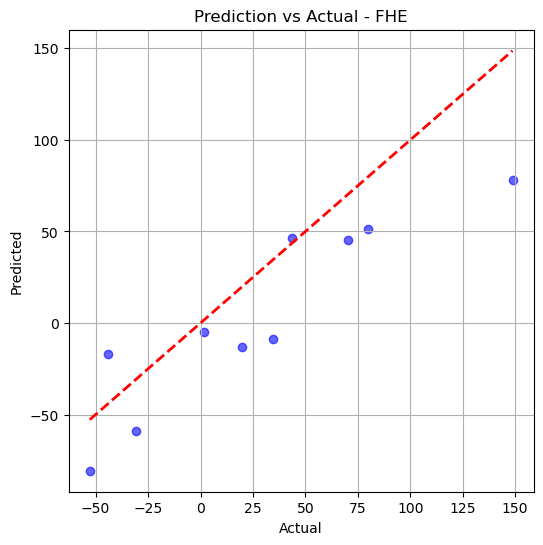

In [12]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_fhe, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Prediction vs Actual - FHE")
plt.grid(True)
plt.show()

### Residual Plot - FHE
- Visualizes the errors (residuals) between predicated and actual values
- Points randomly scattered around the red line (y=0) indicate a good fit
- A clear pattern or curve in the residuals suggests the model is missing some structure in the data
- Large spread in residuals implies high variance or inconsistent predictions
- CLustering or funnel shapes can signal uneven variance

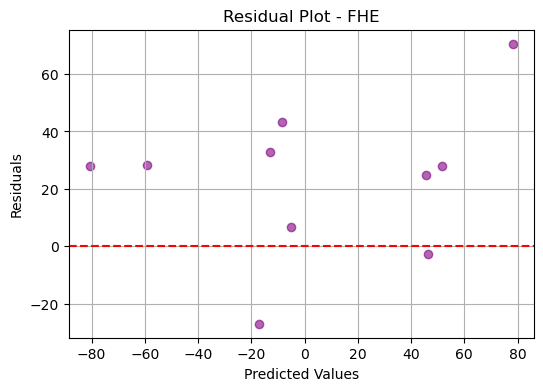

In [13]:
residuals = y_test - y_pred_fhe

plt.figure(figsize=(6, 4))
plt.scatter(y_pred_fhe, residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - FHE")
plt.grid(True)
plt.show()

### Residual Histogram - FHE
- Shows the distribution of prediction errors
- Bell-shaped distribution indicates that the model's errors are random and unbiased
- Skewed or lopsided histograms suggest systematic error or bias in predictions
- Multiple peaks may indicate missing variables or mixed patterns in the data
- Long tails imply the presence of outliers or exterme prediction errors

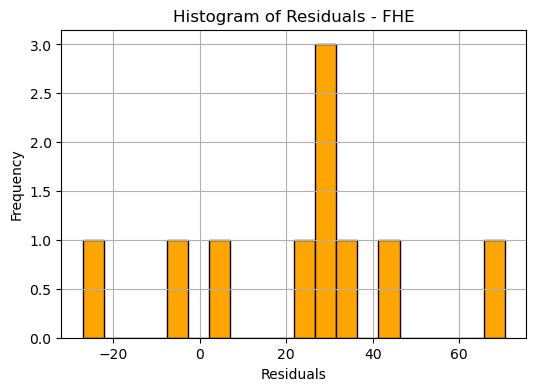

In [14]:
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=20, color='orange', edgecolor='black')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals - FHE")
plt.grid(True)
plt.show()

### Evaluation of Model
- Shows predictions made by the model running on the plaintext (clear)
- Shows predictions made by the model running on the encrypted text
- Similarity shows how often the FHE predictions match the plaintext one
- Shows total runtime of the process of training/test/FHE

In [15]:
print("In clear  :", y_pred_clear)
print("In FHE    :", y_pred_fhe)
print(f"Similarity: {int((y_pred_fhe == y_pred_clear).mean()*100)}%")

total_end_time = time.time()
total_elapsed_time = total_end_time - total_start_time
print(f"Total time for model to Run: {total_elapsed_time:.5f} seconds")

In clear  : [-59.23225407  78.1179003   45.49723863 -12.87657697  -5.15063079
  -8.58438465 -17.1687693  -80.69321569  46.3556771   51.50630789]
In FHE    : [-59.23225407  78.1179003   45.49723863 -12.87657697  -5.15063079
  -8.58438465 -17.1687693  -80.69321569  46.3556771   51.50630789]
Similarity: 100%
Total time for model to Run: 1.25070 seconds


### Evaluation of all results (from each model)

In [16]:
results = {
     '100 Dataset':["100", 
     f"{(y_pred_fhe == y_pred_clear).mean() * 100:.0f}%", 
     ml_elapsed_time,
     clear_mse,
     clear_mae,
     clear_mape,
     clear_r2,
     clear_explained_var,
     fhe_mse,
     fhe_mae,
     fhe_mape,
     fhe_r2,
     fhe_explained_var,
     fhe_elapsed_time,
     total_elapsed_time]
}

headers = ['Samples', 'Similarity', 'ML Time', 'CT MSE','CT MAE', 'CT MAPE', 'CT R2', 'CT EVS', 
           'FHE MSE', 'FHE MAE', 'FHE MAPE', 'FHE R2', 'FHE EVS', 'FHE TIME', 'Total Time']

overall_results = pd.DataFrame(results, index=headers).T.round(2)
overall_results

,Samples,Similarity,ML Time,CT MSE,CT MAE,CT MAPE,CT R2,CT EVS,FHE MSE,FHE MAE,FHE MAPE,FHE R2,FHE EVS,FHE TIME,Total Time
100 Dataset,100,100%,0.157597,1170.14699,29.235289,1.026348,0.668436,0.822146,1170.14699,29.235289,1.026348,0.668436,0.822146,0.502601,1.250702
